<a href="https://colab.research.google.com/github/sondebisola/GroupA--MAITM6341SP25Midterm/blob/main/DEMO_ANN_on_MNIST_Handwriting_Softmax_LONG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import time  # Import the time module
import random
import os
import json
from datetime import datetime

In [2]:
RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

EPOCHS = 100
PATIENCE = 5
RANDOM_SEED = 23
BATCH_SIZE = 32

In [3]:
# Create a timestamp string
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create project directories
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("reports/classification_report", exist_ok=True)
os.makedirs("reports/confusion_matrix", exist_ok=True)
os.makedirs("reports/training_history", exist_ok=True)
os.makedirs("reports/logs", exist_ok=True)

# Function to log saved file paths
log_file_path = f"reports/logs/run_log_{timestamp}.log"

# Initialize log file (clear/create at start)
with open(log_file_path, "w", encoding="utf-8") as log_file:
    log_file.write("RUN LOG\n")
    log_file.write("="*60 + "\n")
    
saved_files = []

def log_message(message):
    message = str(message)  # Ensure message is a string
    print(message)
    #safe_message = str(message).encode("utf-8", errors="replace").decode("utf-8")
    with open(log_file_path, "a", encoding="utf-8") as log_file:
        log_file.write(message + "\n")

def log_save(filepath):
    try:
        full_path = os.path.abspath(filepath)
        saved_files.append(full_path)
        log_message(f"[SUCCESS] Saved → {full_path}")
    except Exception as e:
        log_message(f"[ERROR] Failed to save {filepath}: {str(e)}")

## Prepare the data

In [4]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

## Data Quality Checks

In [5]:
# 1. Check for missing values (NaN/null)
print("="*60)
print("MISSING VALUE CHECKS")
print("="*60)
print(f"Training data - NaN count in X: {np.isnan(x_train).sum()}")
print(f"Training data - NaN count in y: {np.isnan(y_train).sum()}")
print(f"Test data - NaN count in X: {np.isnan(x_test).sum()}")
print(f"Test data - NaN count in y: {np.isnan(y_test).sum()}")

# 2. Shape validation - verify all images are 28x28
print("\n" + "="*60)
print("SHAPE VALIDATION")
print("="*60)
expected_shape = (28, 28)
print(f"Expected image shape: {expected_shape}")
print(f"All training images have correct shape: {all(img.shape == expected_shape for img in x_train)}")
print(f"All test images have correct shape: {all(img.shape == expected_shape for img in x_test)}")

# 3. Pixel range validation - check values are 0-255 before normalization
print("\n" + "="*60)
print("PIXEL RANGE VALIDATION (Before Normalization)")
print("="*60)
print(f"Training data - Min pixel value: {x_train.min()}")
print(f"Training data - Max pixel value: {x_train.max()}")
print(f"Test data - Min pixel value: {x_test.min()}")
print(f"Test data - Max pixel value: {x_test.max()}")
print(f"All pixel values in valid range [0, 255]: {x_train.min() >= 0 and x_train.max() <= 255 and x_test.min() >= 0 and x_test.max() <= 255}")

# 4. Label validation - verify labels are within expected range (0-9)
print("\n" + "="*60)
print("LABEL VALIDATION")
print("="*60)
unique_train_labels = np.unique(y_train)
unique_test_labels = np.unique(y_test)
print(f"Unique training labels: {unique_train_labels}")
print(f"Unique test labels: {unique_test_labels}")
print(f"All training labels in range [0, 9]: {y_train.min() >= 0 and y_train.max() <= 9}")
print(f"All test labels in range [0, 9]: {y_test.min() >= 0 and y_test.max() <= 9}")

# 5. Detect corrupted images - all-black or all-white images
print("\n" + "="*60)
print("CORRUPTED IMAGE DETECTION")
print("="*60)
all_black_train = np.sum([np.all(img == 0) for img in x_train])
all_white_train = np.sum([np.all(img == 255) for img in x_train])
all_black_test = np.sum([np.all(img == 0) for img in x_test])
all_white_test = np.sum([np.all(img == 255) for img in x_test])

print(f"Training data - All-black images: {all_black_train}")
print(f"Training data - All-white images: {all_white_train}")
print(f"Test data - All-black images: {all_black_test}")
print(f"Test data - All-white images: {all_white_test}")

# 6. Check for duplicate images
print("\n" + "="*60)
print("DUPLICATE DETECTION")
print("="*60)
# Flatten images for comparison
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# Check for duplicates within training set
unique_train = np.unique(x_train_flat, axis=0)
duplicates_train = x_train.shape[0] - unique_train.shape[0]
print(f"Duplicate images in training set: {duplicates_train}")

# Check for duplicates within test set
unique_test = np.unique(x_test_flat, axis=0)
duplicates_test = x_test.shape[0] - unique_test.shape[0]
print(f"Duplicate images in test set: {duplicates_test}")

print("\n" + "="*60)
print("DATA QUALITY CHECK COMPLETE ✓")
print("="*60)

MISSING VALUE CHECKS
Training data - NaN count in X: 0
Training data - NaN count in y: 0
Test data - NaN count in X: 0
Test data - NaN count in y: 0

SHAPE VALIDATION
Expected image shape: (28, 28)
All training images have correct shape: True
All test images have correct shape: True

PIXEL RANGE VALIDATION (Before Normalization)
Training data - Min pixel value: 0
Training data - Max pixel value: 255
Test data - Min pixel value: 0
Test data - Max pixel value: 255
All pixel values in valid range [0, 255]: True

LABEL VALIDATION
Unique training labels: [0 1 2 3 4 5 6 7 8 9]
Unique test labels: [0 1 2 3 4 5 6 7 8 9]
All training labels in range [0, 9]: True
All test labels in range [0, 9]: True

CORRUPTED IMAGE DETECTION
Training data - All-black images: 0
Training data - All-white images: 0
Test data - All-black images: 0
Test data - All-white images: 0

DUPLICATE DETECTION
Duplicate images in training set: 0
Duplicate images in test set: 0

DATA QUALITY CHECK COMPLETE ✓


In [6]:
print("TRAINNG DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_train.shape)
# Can see that we have one label for each of the 60,000 images
print(y_train.shape)

print("\nTESTING DATA")
# Can see that in x data we have 10,000 28x28 pixel images
print(x_test.shape)
# Can see that we have one label for each of the 10,000 images
print(y_test.shape)

print('\n Testing to Training ratio =', x_test.shape[0]/x_train.shape[0])

TRAINNG DATA
(60000, 28, 28)
(60000,)

TESTING DATA
(10000, 28, 28)
(10000,)

 Testing to Training ratio = 0.16666666666666666


In [7]:
# Can see each element in x data is 28x28 array where each value is the grayscale value of the pixel from 0-255 where black(255)/white(0)
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [8]:
# Normalize the x data to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
# Can see that we successfully normalized x data
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [10]:
# Can see that the target value is the correct digit 0-9
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [11]:
# Count the number of occurrences of each class in y_train and y_test
train_class_counts = np.bincount(y_train)
test_class_counts = np.bincount(y_test)

# Print the counts for the training data
print("Class counts in the training data:")
for i in range(len(train_class_counts)):
    print(f"Digit {i}: {train_class_counts[i]} samples")

# Print the counts for the test data
print("\nClass counts in the test data:")
for i in range(len(test_class_counts)):
    print(f"Digit {i}: {test_class_counts[i]} samples")

Class counts in the training data:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Class counts in the test data:
Digit 0: 980 samples
Digit 1: 1135 samples
Digit 2: 1032 samples
Digit 3: 1010 samples
Digit 4: 982 samples
Digit 5: 892 samples
Digit 6: 958 samples
Digit 7: 1028 samples
Digit 8: 974 samples
Digit 9: 1009 samples


In [12]:
# Split the training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=x_test.shape[0], random_state=RANDOM_SEED)

In [13]:
# Can see that we have 50,000 training samples after the split
print("TRAINING DATA")
print(x_train.shape)

# Can see that we have 10,000 validation samples after the split
print("\nVALIDATION DATA")
print(x_val.shape)

# Can see that we have 10,000 testing samples
print("\nTEST DATA")
print(x_test.shape)

# Run this cell to see train/val/test split by proportion
total_data_size = x_train.shape[0] + x_val.shape[0] + x_test.shape[0]
print("\nTraining data proportion:", x_train.shape[0]/total_data_size)
print("Validation data proportion:", x_val.shape[0]/total_data_size)
print("Testing data proportion:", x_test.shape[0]/total_data_size)

TRAINING DATA
(50000, 28, 28)

VALIDATION DATA
(10000, 28, 28)

TEST DATA
(10000, 28, 28)

Training data proportion: 0.7142857142857143
Validation data proportion: 0.14285714285714285
Testing data proportion: 0.14285714285714285


## Build and Train the Model (with Hyperparameter Optimization & Regularization)

**Architecture Justification**: The network uses two hidden layers with 64 and 32 neurons. These sizes were chosen to gradually reduce dimensionality (784 → 64 → 32 → 10) while maintaining sufficient capacity to learn digit features. Dropout (rate 0.2) is added after each hidden layer to prevent overfitting – a common issue in fully connected networks. The output layer uses 10 neurons with softmax for multi-class classification.

**Learning Rate Scheduling**: `ReduceLROnPlateau` is used to dynamically lower the learning rate when validation loss plateaus, helping the model converge more effectively.

**Metrics Tracking**: In addition to accuracy, we track precision, recall, and F1-score (macro-averaged) on the validation set every epoch via a custom callback. This provides a more complete picture of model performance, especially important for multi-class tasks where accuracy alone can be misleading.

In [14]:
# Build the neural network with dropout and optimized layer sizes
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),          # Input layer
    keras.layers.Flatten(),                      # Flatten 28x28 images
    keras.layers.Dense(64, activation='relu'),   # First hidden layer (reduced from arbitrary 25)
    keras.layers.Dropout(0.2),                   # Regularization to prevent overfitting
    keras.layers.Dense(32, activation='relu'),   # Second hidden layer (reduced from arbitrary 15)
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax') # Output layer (10 classes)
])

# Compile the model (Adam will be adjusted by learning rate scheduler)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
# total number of parameters in model
total_params = model.count_params()
print(f"Total number of parameters: {total_params}")

# total number of trainable parameters in model
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
print(f"Number of trainable parameters: {trainable_params}")

Total number of parameters: 52650
Number of trainable parameters: 52650


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# --- Custom Callback to track Precision, Recall, F1 on validation set each epoch ---
class MetricsCallback(keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data
        self.history = {'val_precision': [], 'val_recall': [], 'val_f1': []}

    def on_epoch_end(self, epoch, logs=None):
        x_val, y_val = self.validation_data
        y_pred_probs = self.model.predict(x_val, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        # Macro average (suitable for balanced multi-class)
        precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
        self.history['val_precision'].append(precision)
        self.history['val_recall'].append(recall)
        self.history['val_f1'].append(f1)
        # Also add to logs so that they appear in the progress bar and history
        logs['val_precision'] = precision
        logs['val_recall'] = recall
        logs['val_f1'] = f1

# --- Learning Rate Scheduler (ReduceLROnPlateau) ---
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Reduce LR by half
    patience=3,          # Wait 3 epochs before reducing
    min_lr=1e-6,         # Lower bound
    verbose=1
)

# --- Early Stopping ---
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True
)

# --- Model Checkpoint (Save Best Model) ---
model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=f"models/best_model_{timestamp}.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# --- Metrics Callback ---
metrics_cb = MetricsCallback(validation_data=(x_val, y_val))

# --- Train the Neural Network ---
start_time = time.time()
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_scheduler, model_checkpoint, metrics_cb],
    batch_size=BATCH_SIZE,
    verbose=1
)
end_time = time.time()
training_time = end_time - start_time
print("Training Time: {:.2f} seconds".format(training_time))

Epoch 1/100
1535/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7618 - loss: 0.7647
Epoch 1: val_loss improved from None to 0.19485, saving model to models/best_model_20260413_125829.keras

Epoch 1: finished saving model to models/best_model_20260413_125829.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8565 - loss: 0.4791 - val_accuracy: 0.9418 - val_loss: 0.1949 - learning_rate: 0.0010 - val_precision: 0.9413 - val_recall: 0.9413 - val_f1: 0.9411
Epoch 2/100
1550/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9245 - loss: 0.2655
Epoch 2: val_loss improved from 0.19485 to 0.13929, saving model to models/best_model_20260413_125829.keras

Epoch 2: finished saving model to models/best_model_20260413_125829.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9275 - loss: 0.2503 - val_accuracy: 0.9581 - val_loss: 0.1393 - learning_rate: 0.0010 - val_precision: 0.9575 - val_recall: 0.9576 - val_f1: 0.9575
Epoch 3/100
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

In [18]:
# Load the best model saved during training
best_model_path = f"models/best_model_{timestamp}.keras"

if os.path.exists(best_model_path):
    log_save(best_model_path)
else:
    log_message("[WARNING] Best model file not found!")

# Save final trained model
final_model_path = f"models/final_model_{timestamp}.keras"
model.save(final_model_path)

log_save(final_model_path)

# Save training history
history_path = f"reports/training_history/training_history_{timestamp}.json"

with open(history_path, "w") as f:
    json.dump(history.history, f, indent=4, sort_keys=True)

log_save(history_path)

[SUCCESS] Saved → c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\models\best_model_20260413_125829.keras
[SUCCESS] Saved → c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\models\final_model_20260413_125829.keras
[SUCCESS] Saved → c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\reports\training_history\training_history_20260413_125829.json


[SUCCESS] Saved → c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\plots\learning_curves_20260413_125829.png


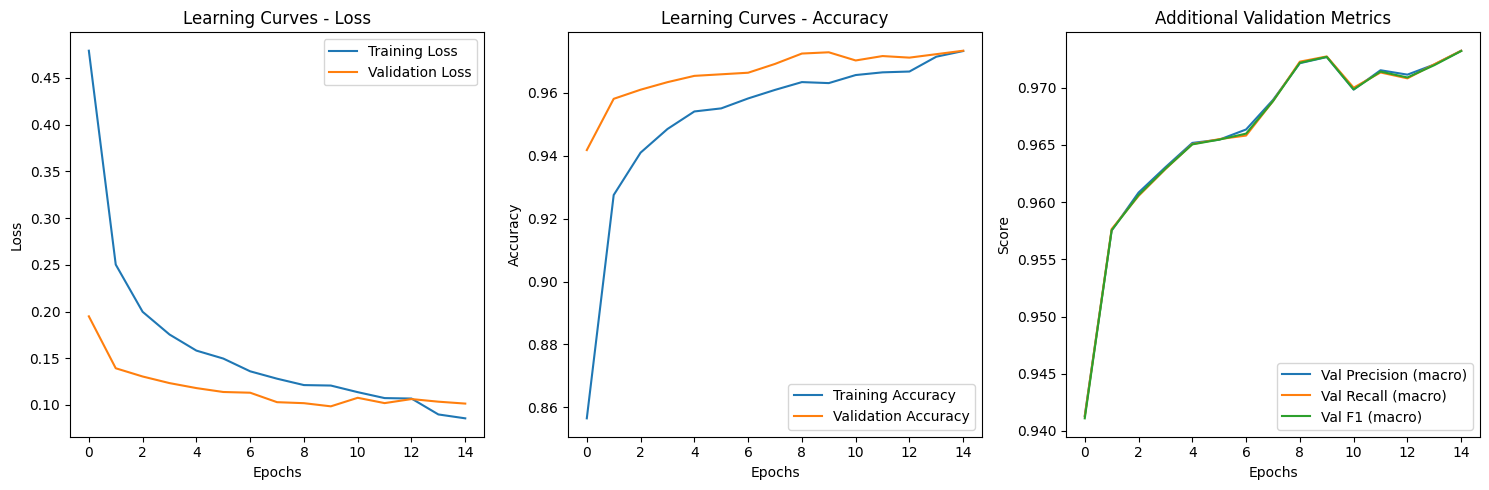

Learning curves saved!


In [19]:
# Plot learning curves including precision, recall, F1
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curves - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Learning Curves - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
# Add precision, recall, f1 from custom callback
if 'val_precision' in history.history:
    plt.plot(history.history['val_precision'], label='Val Precision (macro)')
    plt.plot(history.history['val_recall'], label='Val Recall (macro)')
    plt.plot(history.history['val_f1'], label='Val F1 (macro)')
plt.title('Additional Validation Metrics')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()

lc_path = f"plots/learning_curves_{timestamp}.png"
plt.savefig(lc_path)

log_save(lc_path)
plt.show()

log_message("Learning curves saved!")

## Evaluation

In [20]:
# Load best model from disk
best_model_path = f"models/best_model_{timestamp}.keras"
model = keras.models.load_model(best_model_path)

# Have model make predictions on test data
y_pred = model.predict(x_test)

# Convert predictions to class labels
y_pred = np.argmax(y_pred, axis=1)

print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]



Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.95      0.96       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

[SUCCESS] Saved → c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\reports\classification_report\classification_report_20260413_125829.txt
[SUCCESS] Saved → c:\Users\patel\OneDrive\

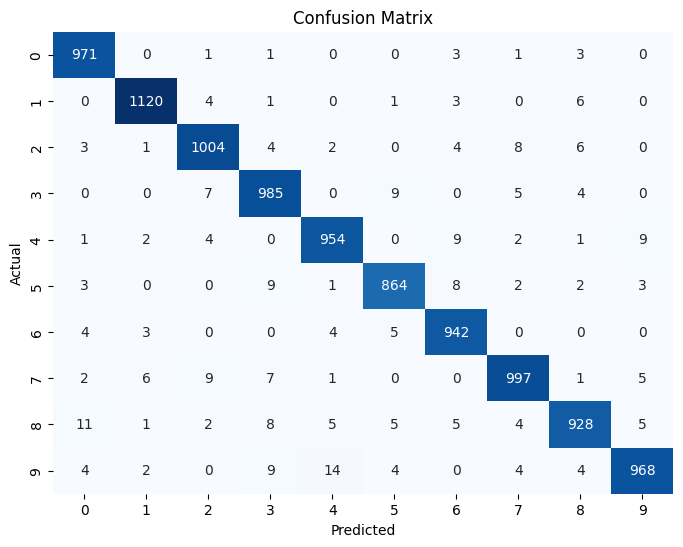

[SUCCESS] Saved → c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\reports\confusion_matrix\confusion_matrix_20260413_125829.json
Confusion matrix saved!


In [21]:
# Print classification report (includes precision, recall, f1 per class)

report = classification_report(y_test, y_pred)

print("\nClassification Report:\n", report)

# Save classification report to text file for human-readable output and JSON file for structured data
txt_path = f"reports/classification_report/classification_report_{timestamp}.txt"

with open(txt_path, "w") as f:
    f.write("Classification Report\n")
    f.write("="*50 + "\n\n")
    f.write(report)

log_save(txt_path)

report_dict = classification_report(y_test, y_pred, output_dict=True)

json_path = f"reports/classification_report/classification_report_{timestamp}.json"

with open(json_path, "w") as f:
    json.dump(report_dict, f, indent=4)

log_save(json_path)

log_message("Classification report saved!")

# Make confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plot_path = f"plots/confusion_matrix_{timestamp}.png"
plt.savefig(plot_path)

log_save(plot_path)
plt.show()

cm_path = f"reports/confusion_matrix/confusion_matrix_{timestamp}.json"

with open(cm_path, "w") as f:
    json.dump(conf_matrix.tolist(), f, indent=4)

log_save(cm_path)

log_message("Confusion matrix saved!")

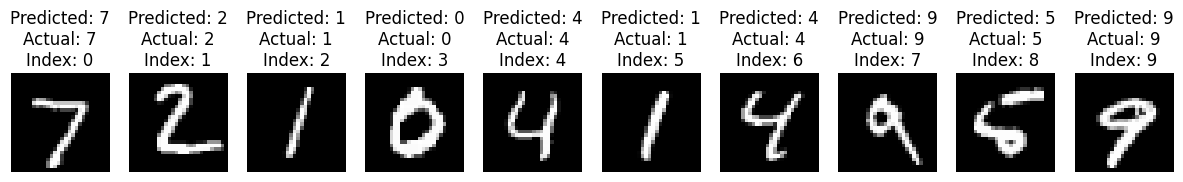

In [22]:
# Display some test images and their predicted labels
num_samples = 10
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}\nActual: {y_test[i]}\nIndex: {i}")
    plt.axis('off')
plt.show()


PREDICTION ERRORS



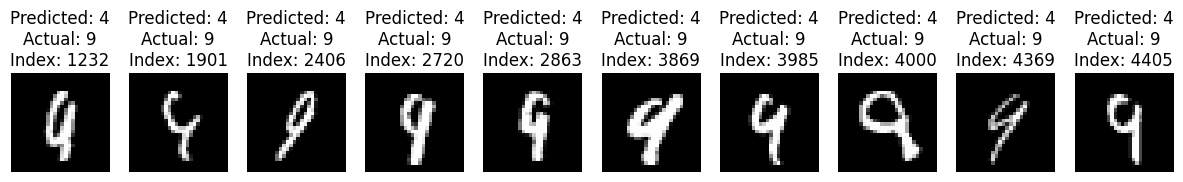

In [23]:
# Select the indices of the worst categorized images
missed_indices = np.where( (y_pred==4) & (y_test==9) )[0]

# Determine the number of samples to display (up to 10)
num_samples = min(len(missed_indices), 10)

print('PREDICTION ERRORS\n')

# Display the predicted '1' images
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    idx = missed_indices[i]
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Predicted: {y_pred[idx]}\nActual: {y_test[idx]}\nIndex: {idx}")
    plt.axis('off')
plt.show()

PREDICTION ERRORS



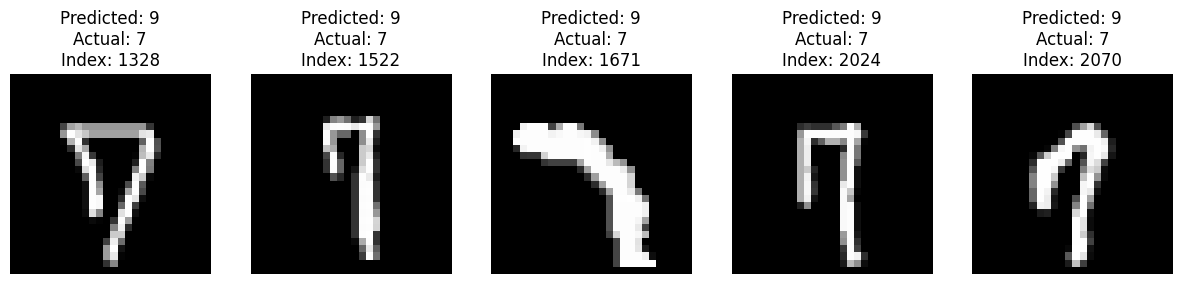

In [24]:
# Select the indices of the worst categorized images
missed_indices = np.where( (y_pred==9) & (y_test==7) )[0]

# Determine the number of samples to display (up to 10)
num_samples = min(len(missed_indices), 10)

print('PREDICTION ERRORS\n')

# Display the predicted '1' images
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    idx = missed_indices[i]
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Predicted: {y_pred[idx]}\nActual: {y_test[idx]}\nIndex: {idx}")
    plt.axis('off')
plt.show()

PREDICTION ERRORS



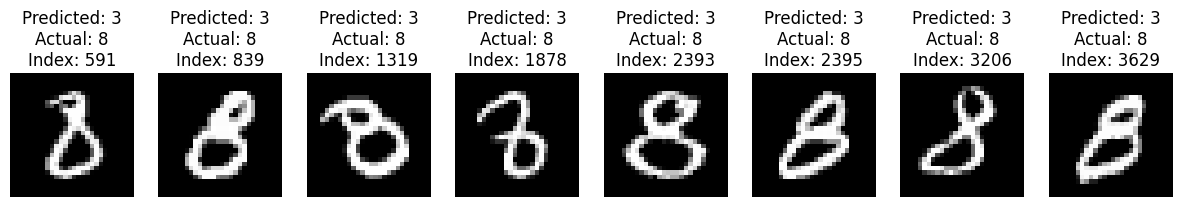

In [25]:
# Select the indices of the worst categorized images
missed_indices = np.where( (y_pred==3) & (y_test==8) )[0]

# Determine the number of samples to display (up to 10)
num_samples = min(len(missed_indices), 10)

print('PREDICTION ERRORS\n')

# Display the predicted '1' images
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    idx = missed_indices[i]
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Predicted: {y_pred[idx]}\nActual: {y_test[idx]}\nIndex: {idx}")
    plt.axis('off')
plt.show()

In [26]:
log_save(log_file_path)

# ---------------- RUN SUMMARY ----------------
log_message("\n" + "="*60)
log_message("RUN SUMMARY")
log_message("="*60)

log_message(f"Timestamp: {timestamp}")
log_message(f"Training Time: {training_time:.2f} seconds")

log_message("\nSaved Files:")
for file in saved_files:
    log_message(f" - {file}")

log_message("\nRun completed successfully!")
log_message("="*60)

[SUCCESS] Saved → c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\reports\logs\run_log_20260413_125829.log

RUN SUMMARY
Timestamp: 20260413_125829
Training Time: 65.64 seconds

Saved Files:
 - c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\models\best_model_20260413_125829.keras
 - c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\models\final_model_20260413_125829.keras
 - c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\reports\training_history\training_history_20260413_125829.json
 - c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\plots\learning_curves_20260413_125829.png
 - c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assignments\reports\classification_report\classification_report_20260413_125829.txt
 - c:\Users\patel\OneDrive\Desktop\Desktop\DBU - MSITM\SEM 1\Python\Python Assign

In [27]:
print("\nPROJECT SUMMARY")
print("="*50)
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final test accuracy: {np.mean(y_pred == y_test):.4f}")
print(f"Total training time: {training_time:.2f} seconds")


PROJECT SUMMARY
Best validation accuracy: 0.9734
Final test accuracy: 0.9733
Total training time: 65.64 seconds
